# DSE5002 - Project #1
Andrey Marchenko
9/25/2026

Project Objectives:
The goal of this porject is to analyze dataset comprised of international and domestic salaries for all levels of data scientists, who can lead a team and be paid competitively.


Questions to Address:

1) What does the data set look like?
2) What is the salary difference being offshore vs domestic employees?
3) What does the salary range look like for full-time data scientist who may eventually lead the team?
4) What is competitive salary for this role?
5) Does the company size affect salary range?
6) Does experience affect the salary range?
7) How much experience should our candidate have?
8) What does salary trend look like for these roles?

#LLM Support: Utilized ChatGPT to help refine the questions

In [1]:
#Libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [296]:
salary_df=pd.read_csv("project_1_data.csv")

In [297]:
salary_df.head(5)

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


Question #1:
What does the data set look like?

In [298]:
salary_df.shape

(607, 12)

In [299]:
salary_df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [300]:
salary_df.dtypes

Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [301]:
salary_df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [302]:
# Analysis of duplicates:

salary_df.duplicated().sum()

np.int64(0)

In [303]:
#Verification of Unnamed being a variable or not:

salary_df["Unnamed: 0"].head(5)

0    0
1    1
2    2
3    3
4    4
Name: Unnamed: 0, dtype: int64

In [304]:
# Removing Unnamed:0

salary_df = salary_df.drop(columns=["Unnamed: 0"])

salary_df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


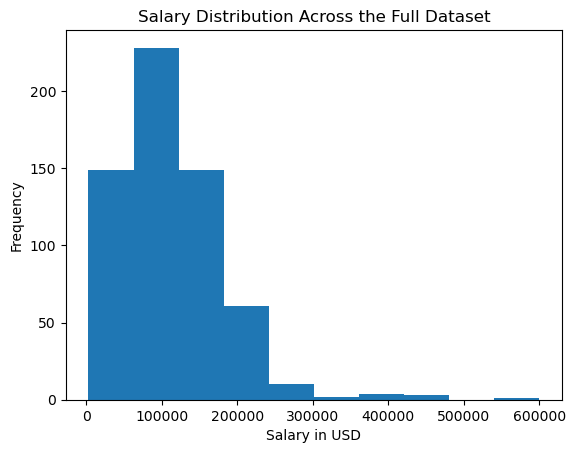

In [305]:
# Plot - Histogram of Salaries in USD to show the distribution:

plt.hist(salary_df["salary_in_usd"])

plt.title("Salary Distribution Across the Full Dataset")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.show()

Observations: 
1) The dataset has 607 rows and 12 collumns
2) The data covers years 2020 through 2022
3) Mean salary = ~$112,297 USD, Min salary = $2,859 USD, Max salary = $600,000 USD, Median salary = $101,570 USD.
4) Maximum salary is much higher than 75% percentile ($600k vs $150k)
5) The data has both numeric and categorical variables
6) No missing data in the dataset
7) Unnamed is an index collumn not a variable. 

Question #2:
What is the salary difference being offshore vs domestic employees?

In [306]:
salary_df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [307]:
salary_df["employee_residence"].value_counts()

employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PT      6
PK      6
BR      6
NL      5
IT      4
RU      4
PL      4
AE      3
TR      3
AU      3
VN      3
AT      3
DK      2
NG      2
HU      2
MX      2
SI      2
RO      2
BE      2
SG      2
PH      1
CN      1
HN      1
NZ      1
UA      1
IQ      1
CL      1
MT      1
IR      1
CO      1
HR      1
BG      1
KE      1
MD      1
RS      1
HK      1
LU      1
JE      1
CZ      1
PR      1
AR      1
DZ      1
MY      1
TN      1
EE      1
BO      1
IE      1
CH      1
Name: count, dtype: int64

In [308]:
#Mean salaries by country:

salary_df.groupby(["employee_residence"])["salary_in_usd"].mean()

employee_residence
AE    100000.000000
AR     60000.000000
AT     76738.666667
AU    108042.666667
BE     85699.000000
BG     80000.000000
BO     75000.000000
BR     54634.666667
CA     97085.310345
CH    122346.000000
CL     40038.000000
CN     43331.000000
CO     21844.000000
CZ     69999.000000
DE     85552.560000
DK     37252.500000
DZ    100000.000000
EE     32974.000000
ES     57593.400000
FR     59886.611111
GB     81403.159091
GR     56331.230769
HK     66022.000000
HN     20000.000000
HR     45618.000000
HU     35997.000000
IE     71444.000000
IN     37322.333333
IQ    100000.000000
IR      4000.000000
IT     61600.000000
JE    100000.000000
JP    103537.714286
KE      9272.000000
LU     59102.000000
MD     18000.000000
MT     28369.000000
MX     18185.000000
MY    200000.000000
NG     30000.000000
NL     60956.600000
NZ    125000.000000
PH     45760.000000
PK     27462.833333
PL     56177.500000
PR    160000.000000
PT     42862.500000
RO     51419.000000
RS     25532.000000
R

In [309]:
# US salary ave (USD): 

us_salary = salary_df[salary_df["employee_residence"] == "US"]

us_salary["salary_in_usd"].mean()

np.float64(149194.1174698795)

In [310]:
# Offshore salary ave (USD)
offshore_salary = salary_df[salary_df["employee_residence"] != "US"]

offshore_salary["salary_in_usd"].mean()

np.float64(67754.03636363636)

In [311]:
# Salary difference US - Offshore:

salary_difference =us_salary["salary_in_usd"].mean() - offshore_salary["salary_in_usd"].mean()

salary_difference

np.float64(81440.08110624315)

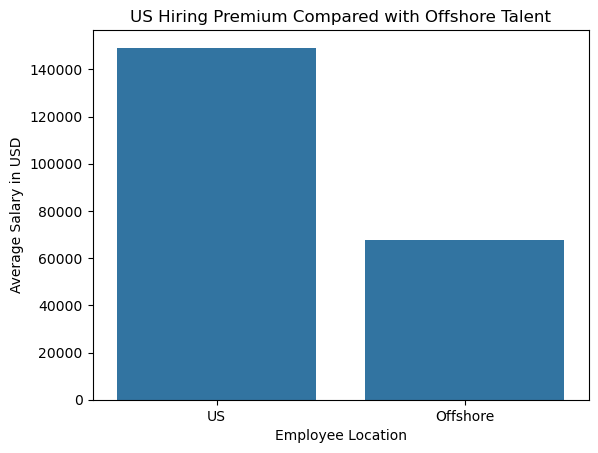

In [312]:
# Plot - Comparison of US vs Offshore salaries:

location_salary = pd.DataFrame({
    "Location": ["US", "Offshore"],
    "Average_Salary": [
        us_salary["salary_in_usd"].mean(),
        offshore_salary["salary_in_usd"].mean()]})

sns.barplot(x="Location", y="Average_Salary", data=location_salary)

plt.title("US Hiring Premium Compared with Offshore Talent")
plt.xlabel("Employee Location")
plt.ylabel("Average Salary in USD")
plt.show()

Observations: 
1) 332 US employees vs 275 Offshore employees
2) US salary ave (USD) = $149,194, PR ave = $160k, MY ave = $200,000 (highest salary
   Note: PR and MY only have 1 data point, which is not comparable to US having 332 data points.
3) Offshore salary ave (USD) = ~ $67,754
4) Salary delta (US vs Offshore in USD) = ~$81,440 (us salaries are higher by $81k)

Question #3:
What does the salary range look like for full-time data scientist who may eventually lead the team?

In [313]:
# Filtering by fulltime eployee:

ft_salary =salary_df[salary_df["employment_type"] == "FT"]

In [314]:
# Filtering by data scientists:

ft_data_scientist = ft_salary[ft_salary["job_title"] == "Data Scientist"]

In [315]:
# Summary of salary distribution:

ft_data_scientist["salary_in_usd"].describe()

count       140.000000
mean     108922.792857
std       64372.431676
min        2859.000000
25%       55490.000000
50%      104796.000000
75%      141975.000000
max      412000.000000
Name: salary_in_usd, dtype: float64

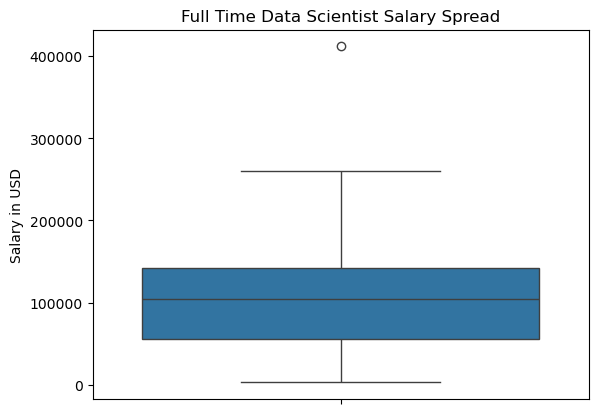

In [316]:
# Plot of full time data science salaries distribution:

sns.boxplot(y="salary_in_usd", data=ft_data_scientist)

plt.title("Full Time Data Scientist Salary Spread")
plt.ylabel("Salary in USD")
plt.show()

In [317]:
# Experience:

ft_data_scientist["experience_level"].value_counts()

experience_level
SE    61
MI    59
EN    20
Name: count, dtype: int64

In [318]:
# Salaries per experience level:

ft_data_scientist.groupby(["experience_level"])["salary_in_usd"].mean()

experience_level
EN     54780.550000
MI     81734.711864
SE    152971.016393
Name: salary_in_usd, dtype: float64

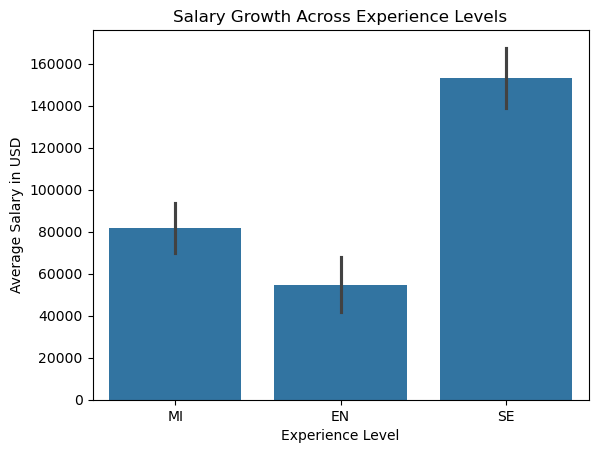

In [319]:
# Plot of Ave salaries vs experience:

sns.barplot(
    x="experience_level",
    y="salary_in_usd",
    data=ft_data_scientist)

plt.title("Salary Growth Across Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary in USD")
plt.show()

Observations (USD): 
1) There are 140 data scientists data points.
2) Min salary = $2,859, Max salary = 412,000, Mean salary = ~108,922, 75% = 141,975
3) There are 61 senior, 59 middle level and 20 entry level data points for fulltime data scientists.
4) Entry level roles earn = ~ $54,780, Middle = ~ $81,734, Senior = ~$152,971

Question #4: 
What is competitive salary for this role?

In [320]:
# Analyzing senior roles only ("eventually lead the team"):

senior_data_scientist = ft_data_scientist[
    ft_data_scientist["experience_level"] == "SE"]

In [321]:
# Filter by US only:

us_senior_data_scientist = senior_data_scientist[
    senior_data_scientist["employee_residence"] == "US"]

In [322]:
# Data summary:

us_senior_data_scientist["salary_in_usd"].describe()

count        51.000000
mean     166796.078431
std       53241.525488
min       80000.000000
25%      139300.000000
50%      150000.000000
75%      205300.000000
max      412000.000000
Name: salary_in_usd, dtype: float64

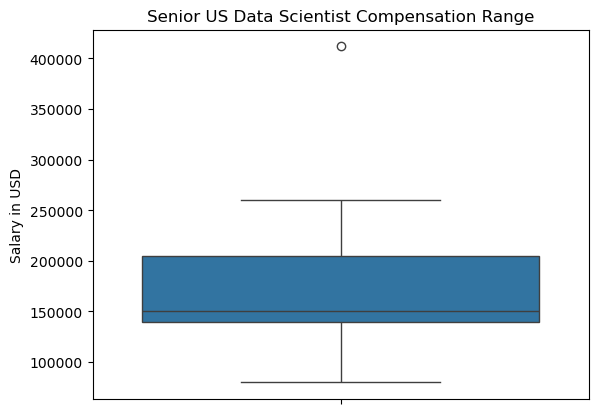

In [323]:
# Plot of Sr level salary distribution in US:

sns.boxplot(y="salary_in_usd", data=us_senior_data_scientist)

plt.title("Senior US Data Scientist Compensation Range")
plt.ylabel("Salary in USD")
plt.show()

Observations (USD):
1) There are 51 full time senior level roles in US
2) Ave salary is ~ 166,796 for these roles
3) Min salary is $80,000
4) Max salary is $412,000
5) 75% is $205,300 (potential recommended salary to be competitive)
6) Salary range is $80,000 to $412,000

Question #5:
Does the company size affect salary range?

In [324]:
us_senior_data_scientist["company_size"].value_counts()

company_size
M    39
L    12
Name: count, dtype: int64

In [325]:
# Comparison of ave saleries for Medium to Large companies in US for Sr. data scientists.

us_senior_data_scientist.groupby(["company_size"])["salary_in_usd"].mean()

company_size
L    183908.333333
M    161530.769231
Name: salary_in_usd, dtype: float64

In [326]:
# Expanding the analysis to all levels of data scientists to understand salaries accross all company sizes.

ft_data_scientist["company_size"].value_counts()

company_size
M    75
L    45
S    20
Name: count, dtype: int64

In [327]:
# Ave salary across all compoany sizes for all data scientists: 

ft_data_scientist.groupby(["company_size"])["salary_in_usd"].mean()

company_size
L    103313.355556
M    127084.240000
S     53438.600000
Name: salary_in_usd, dtype: float64

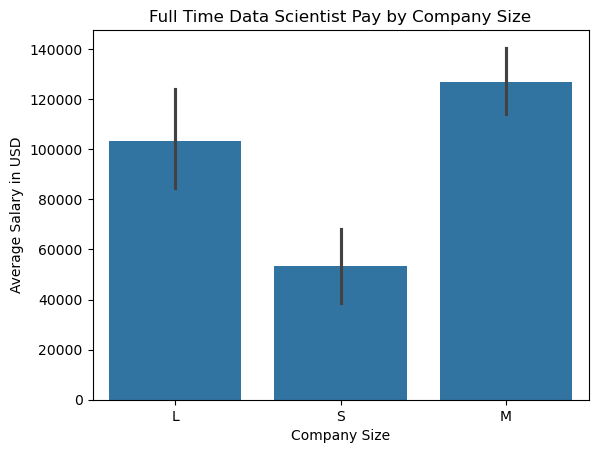

In [328]:
# Plot of ave salaries by company size:

sns.barplot(
    x="company_size",
    y="salary_in_usd",
    data=ft_data_scientist)

plt.title("Full Time Data Scientist Pay by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary in USD")
plt.show()

Observations:
1) The dataset contains 39 people from medium size companies and 12 from large.
2) There is no data points for small size companies in the US (Sr. level roles), which makes it harder to predict what small companies would pay for the same talent. 
3) Ave salary for Sr. data scientists in large companies is ~ $183,908
4) Ave salary for Sr. data scientists in Medium companies is ~ $161,530
5) After expending the analysis accross all company sizes for all data scientists roles, there are 20 data scientists in small companies, 75 in medium and 45 in large.
6) After expending the analysis accross all company sizes for all data scientists roles, ave salaries for small companies are ~$53,438, medium ~$127,084 and $103,313 for large companies.
7) Large and Medium size compapanies pay mich more than at small organizations, with medium companies paying the most.

Question #6:
Does experience affect the salary range?

In [329]:
# Comparison of salaries for all data scientists across different seniority levels:

ft_data_scientist.groupby(["experience_level"])["salary_in_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,20.0,54780.550000,30224.880120,4000.0,34920.0,50483.5,81675.75,105000.0
MI,59.0,81734.711864,47212.036738,2859.0,41339.0,76958.0,118529.50,200000.0
SE,61.0,152971.016393,58985.402166,20171.0,120000.0,140400.0,180000.00,412000.0


Observations:
1) Entry data scientists on average earn ~$54,780, with STD= ~$30,224, Min= $4,000, 
Max= $105,000, and 75% = $81,675
2) Mid data scientists on average earn ~$81,734, with STD= ~$47,212, Min= ~$2,859, Max= $200,000 and 75%= ~$118,529.
3) Senior data scientists on average earn ~$152,971, with STD= ~$58,985, Min= ~20,171, Max= $412,000 and 75%= $180,000.

Question #7:
How much experience should our candidate have?

In [330]:
# Analysis of full time data scientists in US to help us fill the role:

us_ft_data_scientist = ft_data_scientist[
    ft_data_scientist["employee_residence"] == "US"]

us_ft_data_scientist["experience_level"].value_counts()

experience_level
SE    51
MI    21
EN     6
Name: count, dtype: int64

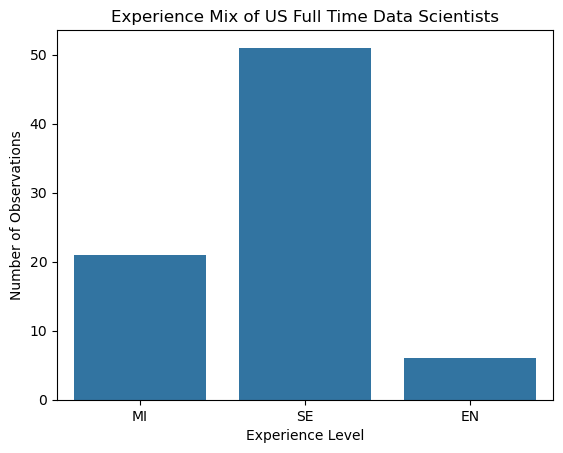

In [331]:
# Plot of US data scientists by experience (full time)

sns.countplot(
    x="experience_level",
    data=us_ft_data_scientist
)

plt.title("Experience Mix of US Full Time Data Scientists")
plt.xlabel("Experience Level")
plt.ylabel("Number of Observations")
plt.show()

Observations:
1) We have 6 entry level roles, 21 medium and 51 senior level.
2) Sr. roles make up the majority of US market accross full time data scientists roles in this dataset.
3) Sr. roles is our target list of candidates that could lead the team and help us fill the role

Question #8:
What does salary trend look like for these roles?

In [332]:
# Analysis of data points per Sr. level in US per year:

us_senior_data_scientist["work_year"].value_counts()

work_year
2022    47
2020     2
2021     2
Name: count, dtype: int64

In [333]:
# Analysis of data points for all levels of data scientists per year:

ft_data_scientist["work_year"].value_counts()

work_year
2022    75
2021    45
2020    20
Name: count, dtype: int64

In [334]:
# Analysis of all full time data scientists per year by salary (USD):

ft_data_scientist.groupby(["work_year"])["salary_in_usd"].mean()

work_year
2020     89185.600000
2021     70671.733333
2022    137136.680000
Name: salary_in_usd, dtype: float64

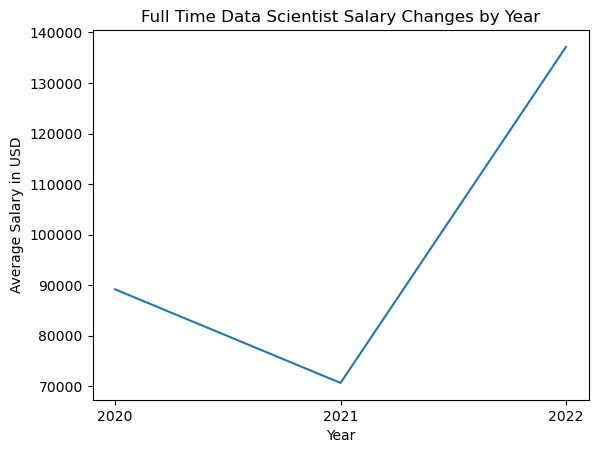

In [335]:
# Salary yearly averages:

salary_by_year = ft_data_scientist.groupby(["work_year"])["salary_in_usd"].mean()

plt.plot(salary_by_year)

plt.title("Full Time Data Scientist Salary Changes by Year")
plt.xlabel("Year")
plt.ylabel("Average Salary in USD")

plt.xticks([2020, 2021, 2022])

plt.show()

Observaion:
1) For Sr. level roles, there's not enough data to create a meaninful trend, where years 2020 and 2021 only have 2 data points each.
2) For all levels data scientists, theres anough data to create a trend (2022=75 data points, 2021=45 data points and 2020=20 data points.
3) Salaries for full time data scientists is varied by year and doesnt show a linear trend (2020= ~$89,185, 2021= ~$70,671 and 2022 = ~$137,136).

In [336]:
# Analysis of experience level in small companies:

small_company_ds = ft_data_scientist[
    ft_data_scientist["company_size"] == "S"]

small_company_ds["experience_level"].value_counts()


experience_level
MI    12
EN     6
SE     2
Name: count, dtype: int64

In [337]:
# Analysis of 2022 salaries for Sr. level roles of full time data scientists:

us_senior_2022 = us_senior_data_scientist[
    us_senior_data_scientist["work_year"] == 2022]

us_senior_2022["salary_in_usd"].describe()

count        47.000000
mean     163289.361702
std       41132.338722
min       80000.000000
25%      140000.000000
50%      150000.000000
75%      205300.000000
max      260000.000000
Name: salary_in_usd, dtype: float64

Final Analysis Summary:

1) For US Sr. level fulltime Data Scientists, the median salary is $150,000 and the 75% is ~$205,300, which supports using these values from the market data.
2) 2022 data shows the same median and 75% ($150,000 and $205,300)
3) The salary average in small companies for full time data scientists are not comparable as there are only 2 data points for Sr level roles that we need.

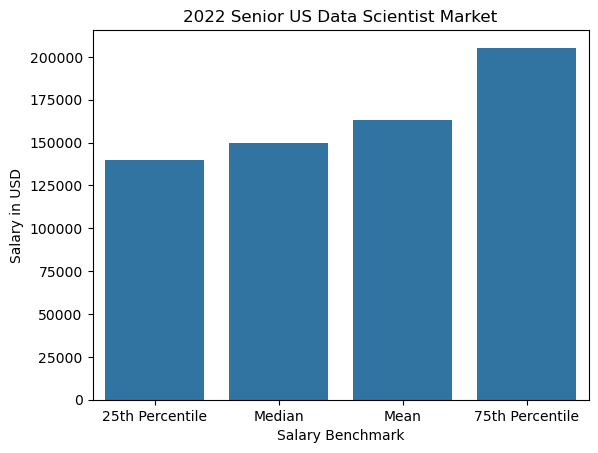

In [338]:
# Plot of US Sr level data scientists in 2022:

salary_benchmarks = pd.DataFrame({
    "Benchmark": ["25th Percentile", "Median", "Mean", "75th Percentile"],
    "Salary": [
        us_senior_2022["salary_in_usd"].quantile(.25),
        us_senior_2022["salary_in_usd"].median(),
        us_senior_2022["salary_in_usd"].mean(),
        us_senior_2022["salary_in_usd"].quantile(.75) ]})

sns.barplot(
    x="Benchmark",
    y="Salary",
    data=salary_benchmarks)

plt.title("2022 Senior US Data Scientist Market")
plt.xlabel("Salary Benchmark")
plt.ylabel("Salary in USD")
plt.show()

Recommendations:

Our organization should utilize $150-205k range to hire Sr. level candidate that could lead a team of data scientists. To be competitive, we could go above the median range and stay slightly under the upper, 75%, and negotiate from $160,000 - $190,000. 